# ScAdver Pancreas Batch Correction

Reference/query projection with automatic routing in `transform_query_adaptive`:
- probe threshold (`||Δ(z)|| > 0.1`)
- overlap/class-count gate (`shared_ratio >= 0.8` and `n_classes <= 40`)

This notebook trains ScAdver on pancreas reference data, projects the held-out query technologies,
saves corrected AnnData, and visualizes final integration.

In [19]:
import os

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import scanpy as sc
import anndata as ad
import torch
import matplotlib.pyplot as plt

import scadver
from scadver import (
    adversarial_batch_correction,
    transform_query_adaptive,
    save_model,
    load_model,
    set_global_seed,
)

SEED = 42
set_global_seed(SEED)

print('✅ Libraries imported')
print(f"   ScAdver : {scadver.__version__}")
print(f"   Scanpy  : {sc.__version__}")
print(f"   Torch   : {torch.__version__}")
print(f"   Device  : {'MPS' if torch.backends.mps.is_available() else 'CPU'}")

✅ Libraries imported
   ScAdver : 1.7.8
   Scanpy  : 1.11.4
   Torch   : 2.8.0
   Device  : MPS


## Step 1 — Load pancreas data and split reference/query

In [14]:
_HERE = os.getcwd()
if not os.path.exists(os.path.join(_HERE, 'human_pancreas_norm_complexBatch.h5ad')):
    maybe_examples = os.path.join(_HERE, 'examples')
    if os.path.exists(os.path.join(maybe_examples, 'human_pancreas_norm_complexBatch.h5ad')):
        _HERE = maybe_examples

DATA_H5AD = os.path.join(_HERE, 'human_pancreas_norm_complexBatch.h5ad')
adata = sc.read_h5ad(DATA_H5AD)

# Keep highly variable genes for stable/faster training
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key='tech', subset=True)

# Held-out query technologies
query_techs = ['smartseq2', 'celseq2']
adata_query = adata[adata.obs['tech'].isin(query_techs)].copy()
adata_ref = adata[~adata.obs['tech'].isin(query_techs)].copy()

bio_label = 'celltype'
batch_label = 'tech'

print('Data split:')
print(f"  Total      : {adata.n_obs:,} cells")
print(f"  Reference  : {adata_ref.n_obs:,} cells")
print(f"  Query      : {adata_query.n_obs:,} cells")
print()
print('Reference technologies:')
print(adata_ref.obs['tech'].value_counts().to_string())
print()
print('Query technologies:')
print(adata_query.obs['tech'].value_counts().to_string())

Data split:
  Total      : 16,382 cells
  Reference  : 11,703 cells
  Query      : 4,679 cells

Reference technologies:
tech
inDrop3       3605
inDrop1       1937
inDrop2       1724
smarter       1492
inDrop4       1303
celseq        1004
fluidigmc1     638

Query technologies:
tech
smartseq2    2394
celseq2      2285


## Step 2 — Train ScAdver on reference

In [3]:
%%time
adata_ref_corrected, model, ref_metrics = adversarial_batch_correction(
    adata=adata_ref,
    bio_label=bio_label,
    batch_label=batch_label,
    latent_dim=256,
    epochs=300,
    learning_rate=0.001,
    batch_weight=0.5,
    device='auto',
    return_reconstructed=True,
    calculate_metrics=False,
    seed=SEED,
)

print()
print('✅ Reference training complete')
print(f"   Embedding shape: {adata_ref_corrected.obsm['X_ScAdver'].shape}")

🚀 ADVERSARIAL BATCH CORRECTION
   Device: mps
📊 DATA PREPARATION:
   Valid samples: 11703/11703
   Input shape: (11703, 2000)
   Biology labels: 14 unique
   Batch labels: 7 unique
   ⚙️  bio_weight='auto' → 20.00 (for 14 classes)
🧠 MODEL ARCHITECTURE:
   Input dimension: 2000
   Latent dimension: 256
   Biology classes: 14
   Batch classes: 7
🏋️ TRAINING MODEL:
   Epochs: 300
   Learning rate: 0.001
   Effective bio weight: 20.00
   Batch weight: 0.5
   Batch size (adaptive): 256 (45 batches/epoch for 11,703 samples)
   Epoch 60/300 - Bio accuracy (Reference): 0.988 (best: 0.988)
   Epoch 120/300 - Bio accuracy (Reference): 0.981 (best: 0.988)
   Epoch 180/300 - Bio accuracy (Reference): 0.980 (best: 0.988)
   Epoch 240/300 - Bio accuracy (Reference): 0.985 (best: 0.988)
   Epoch 300/300 - Bio accuracy (Reference): 0.982 (best: 0.988)
✅ Training completed! Best monitored biology accuracy: 0.988
🔄 GENERATING CORRECTED EMBEDDING:
   Output embedding shape: (11703, 256)
   Reconstructed 

## Step 3 — Save reference model (for future query projection)

In [ ]:
model_out = os.path.join(_HERE, 'scadver_pancreas_ref.pt')
save_model(model, model_out)
print(f'Saved reference model: {model_out}')

# Optional check: load it back
#model = load_model("scadver_pancreas_ref.pt")
#print('Reload check passed')

## Step 4 — Adaptive query projection (auto routing)

In [15]:
%%time
adata_query_corrected = transform_query_adaptive(
    model=model,
    adata_query=adata_query,
    adata_reference=adata_ref,
    bio_label=bio_label,
    adaptation_epochs=120,
    warmup_epochs=30,
    patience=30,
    max_epochs=220,
    learning_rate=0.0007,
    alignment_mode='auto',
    device='auto',
    return_reconstructed=True,
    seed=SEED,
)

print()
print('✅ Query projection complete')
print(f"   Query embedding shape: {adata_query_corrected.obsm['X_ScAdver'].shape}")

🤖 PATH SELECTION...
   14 classes ≤ 100 → running residual probe to check shift magnitude
   Probe: short adapter run (~30 epochs) on 1000 samples
   📊 Residual Probe Analysis:
      ||Δ(z)||: 1.1374  (std 1.1753)
      Metric   : same-class neighbor distance
   🎯 Decision: ADAPTER NEEDED
      Confidence: HIGH
   💡 ||Δ|| > 0.1: raw source shift detected — adapting query toward the reference manifold
   🔀 Adapter mode: neighbor


🔬 ADAPTIVE QUERY PROJECTION (Enhanced)
   Device: mps
   Query samples: 4679
   Reference samples for alignment: 11703
   Bio label      : celltype
   Query classes  : 13
   Ref classifier : 14 output classes
   Shared classes : 13/13
   Shared cells   : 100.0%
   Overlap ratio  : 100.0%
   ✅ Bio supervision ENABLED  — weight = 2.0 (13 classes)
   Conditional alignment: 14 cell types indexed
   Prototype anchors  : 13 class centroids

🧭 NEIGHBOR RESIDUAL MODE: Same-class reference neighborhood pull
   14 classes ≤ 100 with strong label overlap → simplified res

## Step 5 — Save corrected AnnData

In [ ]:
ref_out = os.path.join(_HERE, 'adata_pancreas_ref_corrected.h5ad')
query_out = os.path.join(_HERE, 'adata_pancreas_query_corrected.h5ad')

adata_ref_corrected.write_h5ad(ref_out)
adata_query_corrected.write_h5ad(query_out)

print('Saved:')
print(' ', ref_out)
print(' ', query_out)

## Step 6 — Final UMAP

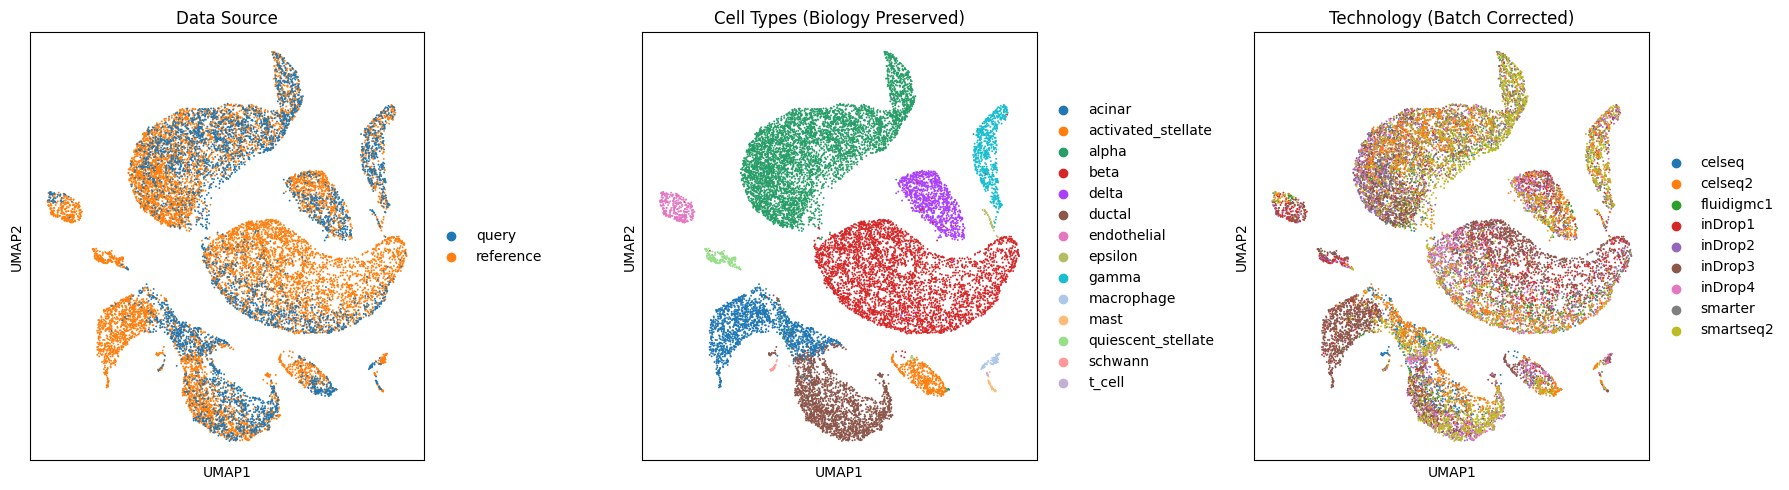

In [17]:
adata_ref_corrected.obs['source'] = 'reference'
adata_query_corrected.obs['source'] = 'query'

adata_ref_query = ad.concat([adata_ref_corrected, adata_query_corrected], join='inner', merge='same')
adata_ref_query.obs_names_make_unique()

sc.pp.neighbors(adata_ref_query, use_rep='X_ScAdver', n_neighbors=15)
sc.tl.umap(adata_ref_query, random_state=SEED)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sc.pl.umap(adata_ref_query, color='source', ax=axes[0], show=False, title='Data Source')
sc.pl.umap(adata_ref_query, color=bio_label, ax=axes[1], show=False, title='Cell Types (Biology Preserved)')
sc.pl.umap(adata_ref_query, color=batch_label, ax=axes[2], show=False, title='Technology (Batch Corrected)')
plt.tight_layout()
plt.show()

In [18]:
adata_ref_query

AnnData object with n_obs × n_vars = 16382 × 2000
    obs: 'tech', 'celltype', 'size_factors', 'source'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'neighbors', 'umap', 'source_colors', 'celltype_colors', 'tech_colors'
    obsm: 'X_ScAdver', 'X_umap'
    layers: 'counts', 'ScAdver_reconstructed'
    obsp: 'distances', 'connectivities'

In [ ]:
# For downstream analysis, you can use the reconstructed data (if returned) or the original data with the new embedding.
adata_downstream = adata_ref_query.copy()
adata_downstream.X = adata_downstream.layers['ScAdver_reconstructed'].copy()